# Introduction

### Configuration

In [1]:
from pathlib import Path

# The cache directories:
cache_path       = '/data/crcns2021/hcpannot-cache'
image_cache_path = f'{cache_path}/annot-images'
v123_cache_path  = f'{cache_path}/annot-v123'
csulc_cache_path = f'{cache_path}/annot-csulc'
results_path = '/data/crcns2021/results'
contour_save_path = f'{results_path}/data_branch/save'
proc_path = f'{results_path}/proc'
traces_path = f'{proc_path}/traces'
paths_path = f'{proc_path}/paths'
labels_path = f'{proc_path}/labels'

hcpannot_lib_path = Path('~/hcp-annot-vc')
#If you aren't using /data
import os
os.environ['HCPANNOT_LOAD_PATH'] = cache_path

### Dependencies

In [2]:
import sys, pimms, pandas, warnings, urllib, datetime
import numpy as np
import pandas as pd
import scipy as sp
import scipy.sparse as sps
import nibabel as nib
import neuropythy as ny

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import ipyvolume as ipv
import torch, json

from collections import defaultdict

In [3]:
%matplotlib inline

In [4]:
# Additional matplotlib preferences:
font_data = {'family':'sans-serif',
             'sans-serif':['HelveticaNeue', 'Helvetica', 'Arial'],
             'size': 10,
             'weight': 'light'}
mpl.rc('font',**font_data)
# we want relatively high-res images, especially when saving to disk.
mpl.rcParams['figure.dpi'] = 72*2
mpl.rcParams['savefig.dpi'] = 72*4

### Import `hcpannot`

In [5]:
# Make sure we are in the right directory for this!
hcpannot_lib_path = Path('~/hcp-annot-vc')

if hcpannot_lib_path:
    hlp = os.path.expandvars(os.fspath(hcpannot_lib_path))
    hlp = os.path.expanduser(hlp)
    if hlp.strip('/').endswith('hcpannot'):
        warnings.warn(
            "adding hcpannot_lib_path that ends with 'hcpannot';"
            " the hcpannot_lib_path should contain the hcpannot directory")
    if os.path.isdir(hlp):
        sys.path.append(hlp)
    else:
        raise ValueError("hcpannot_lib_path is not a directory")
# We try importing it and if we fail, we check to see if we are just running
# the notebook from the work directory and try again.
try:
    import hcpannot
except ModuleNotFoundError:
    hcpannot = None
    if os.getcwd().endswith('/work'):
        hlp = os.path.abspath('..')
        sys.path.append(hlp)

# Note the cache path we want to use outside the docker container;
# normally this gets set by the Docker startup, so here outside
# the docker container we set it manually.
hcpannot.interface.default_load_path = cache_path
# We have to update some data after setting this.

# We also want to grab a few variables from hcpannot:
from hcpannot.interface import default_imshape as roi_image_shape
roi_image_shape = roi_image_shape[0] // 2
from hcpannot.interface import imgrid_to_flatmap
from hcpannot.interface import flatmap_to_imgrid
# The proc (for processing contours):
from hcpannot.proc import (proc, rigid_align_points)
# The functions for loading and saving contours.
from hcpannot import (save_contours, load_contours)

# Subject lists. These are defined in the analysis subpackage of
# the hcpannot library, and subject_list_<x> is the <x>th list of
# subject IDs that we assigned.

### POTENTIAL ISSUE WITH
from hcpannot import subject_list
sids = np.array(hcpannot.subject_list)

# The mean rater's name ('mean') and some plotting functions are also defined in
# the hcpannot.analysis subpackage.
from hcpannot.config import meanrater #plot_vc_contours)

#Finally, we have some multiprocessing tools.
# from hcpannot.mp import (tupcall, okaystr, failstr, retry_sleep, mprun, mpstep,
#                          makejobs)

# TODO: specify what functions to import
from hcpannot.analysis.contour import *

### Usage Notes

Here's an example code-block using the `plot_contours` function to plot a set of boundaries along with the V1-V3 contours.

```python
dat = proc('ventral', rater='BrendaQiu',
              sid=111312,
              hemisphere='lh',
              save_path=proc_path,
              load_path=contour_save_path)
# Make the flatmap plot and the boundaries.
fig = plot_contours(dat, boundaries=True)
# Extract the pyplot axes that were used.
ax = fig.axes[0]
# Grab the subject data, which includes the V1-V3 contours.
sdat = hcpannot.interface.subject_data[(dat['sid'],dat['hemisphere'])]
# And plot all of these contours:
for (x,y) in sdat['v123'].values():
    ax.plot(x, y, 'w-', lw=0.25)
```

## Work

#### Example: Plot all raters' contours of subject 973770

/home/brendaqiu/.conda/envs/cnn/lib/python3.10/site-packages/IPython/core/events.py:89: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  func(*args, **kwargs)
/home/brendaqiu/.conda/envs/cnn/lib/python3.10/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


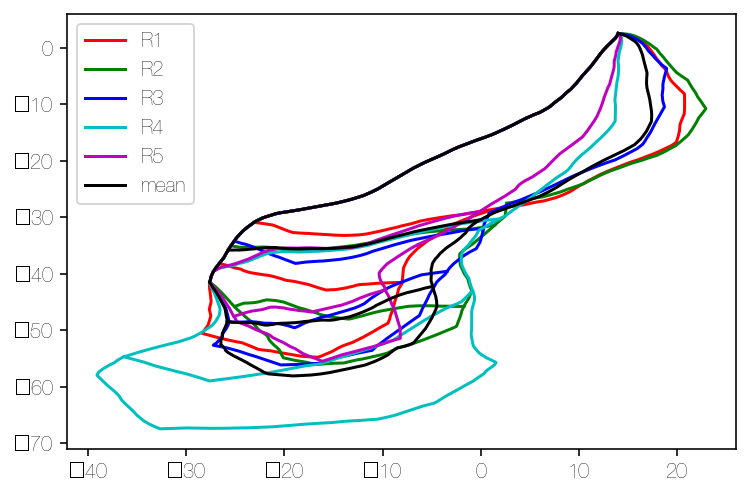

In [6]:
# define contours of interest
contours = ['hV4_outer','hV4_VO1','VO1_VO2','VO_outer', 'V3v']

plot_rater_contours(raters=ventral_raters, subject_id=973770, hemi='rh', contours=contours, save_path=proc_path, 
              data_path=contour_save_path)

#### Check for missing contours

In [7]:
mis_rater = []
mis_sid = []
mis_hemi = []
mis_contour = []
mis_type = []

# iterate over all subjects, raters, hemispheres, and contours
# and check if the contour coordinates have been saved

for roi in contours:
    if roi == 'V3v':
        continue
    else:
        for r in ventral_raters:
            for sid in sids:
                for hemi in ['lh', 'rh']:
                    # check if the cache file exists
                    missing_types = [t for t in ['fsaverage', 'fsnative', 'fsnative_aligned'] 
                                    if not os.path.exists(os.path.join(proc_path, t, f"cacherater_{r}_{sid}_{hemi}_{roi}.mgz"))]

                    # if the cache file does not exist, add the missing information to the list
                    if missing_types:
                        
                        # fsnative and fsnative_aligned are not generated for mean rater
                        # if they are missing, ignore
                        if r == 'mean' and ('fsnative' in missing_types or 'fsnative_aligned' in missing_types):
                            if 'fsaverage' not in missing_types:
                                continue
                            else:
                                missing_types = ['fsaverage']
                        
                        # extend the lists with the missing information        
                        mis_rater.extend([r] * len(missing_types))
                        mis_sid.extend([sid] * len(missing_types))
                        mis_hemi.extend([hemi] * len(missing_types))
                        mis_contour.extend([roi] * len(missing_types))
                        mis_type.extend(missing_types)
            else:
                continue

# create a dataframe of missing information
miss_df = pd.DataFrame({
    'sid': mis_sid,
    'rater': mis_rater,
    'hemi': mis_hemi,
    'contour': mis_contour,
    'type': mis_type
})

miss_df

,sid,rater,hemi,contour,type
0,200210,R5,lh,hV4_outer,fsaverage
1,200210,R5,lh,hV4_outer,fsnative
2,200210,R5,lh,hV4_outer,fsnative_aligned
3,200210,R5,lh,hV4_VO1,fsaverage
4,200210,R5,lh,hV4_VO1,fsnative
5,200210,R5,lh,hV4_VO1,fsnative_aligned
6,200210,R5,lh,VO1_VO2,fsaverage
7,200210,R5,lh,VO1_VO2,fsnative
8,200210,R5,lh,VO1_VO2,fsnative_aligned
9,200210,R5,lh,VO_outer,fsaverage


#### Plot mean contour of each subject

/home/brendaqiu/.conda/envs/cnn/lib/python3.10/site-packages/IPython/core/events.py:89: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  func(*args, **kwargs)
/home/brendaqiu/.conda/envs/cnn/lib/python3.10/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


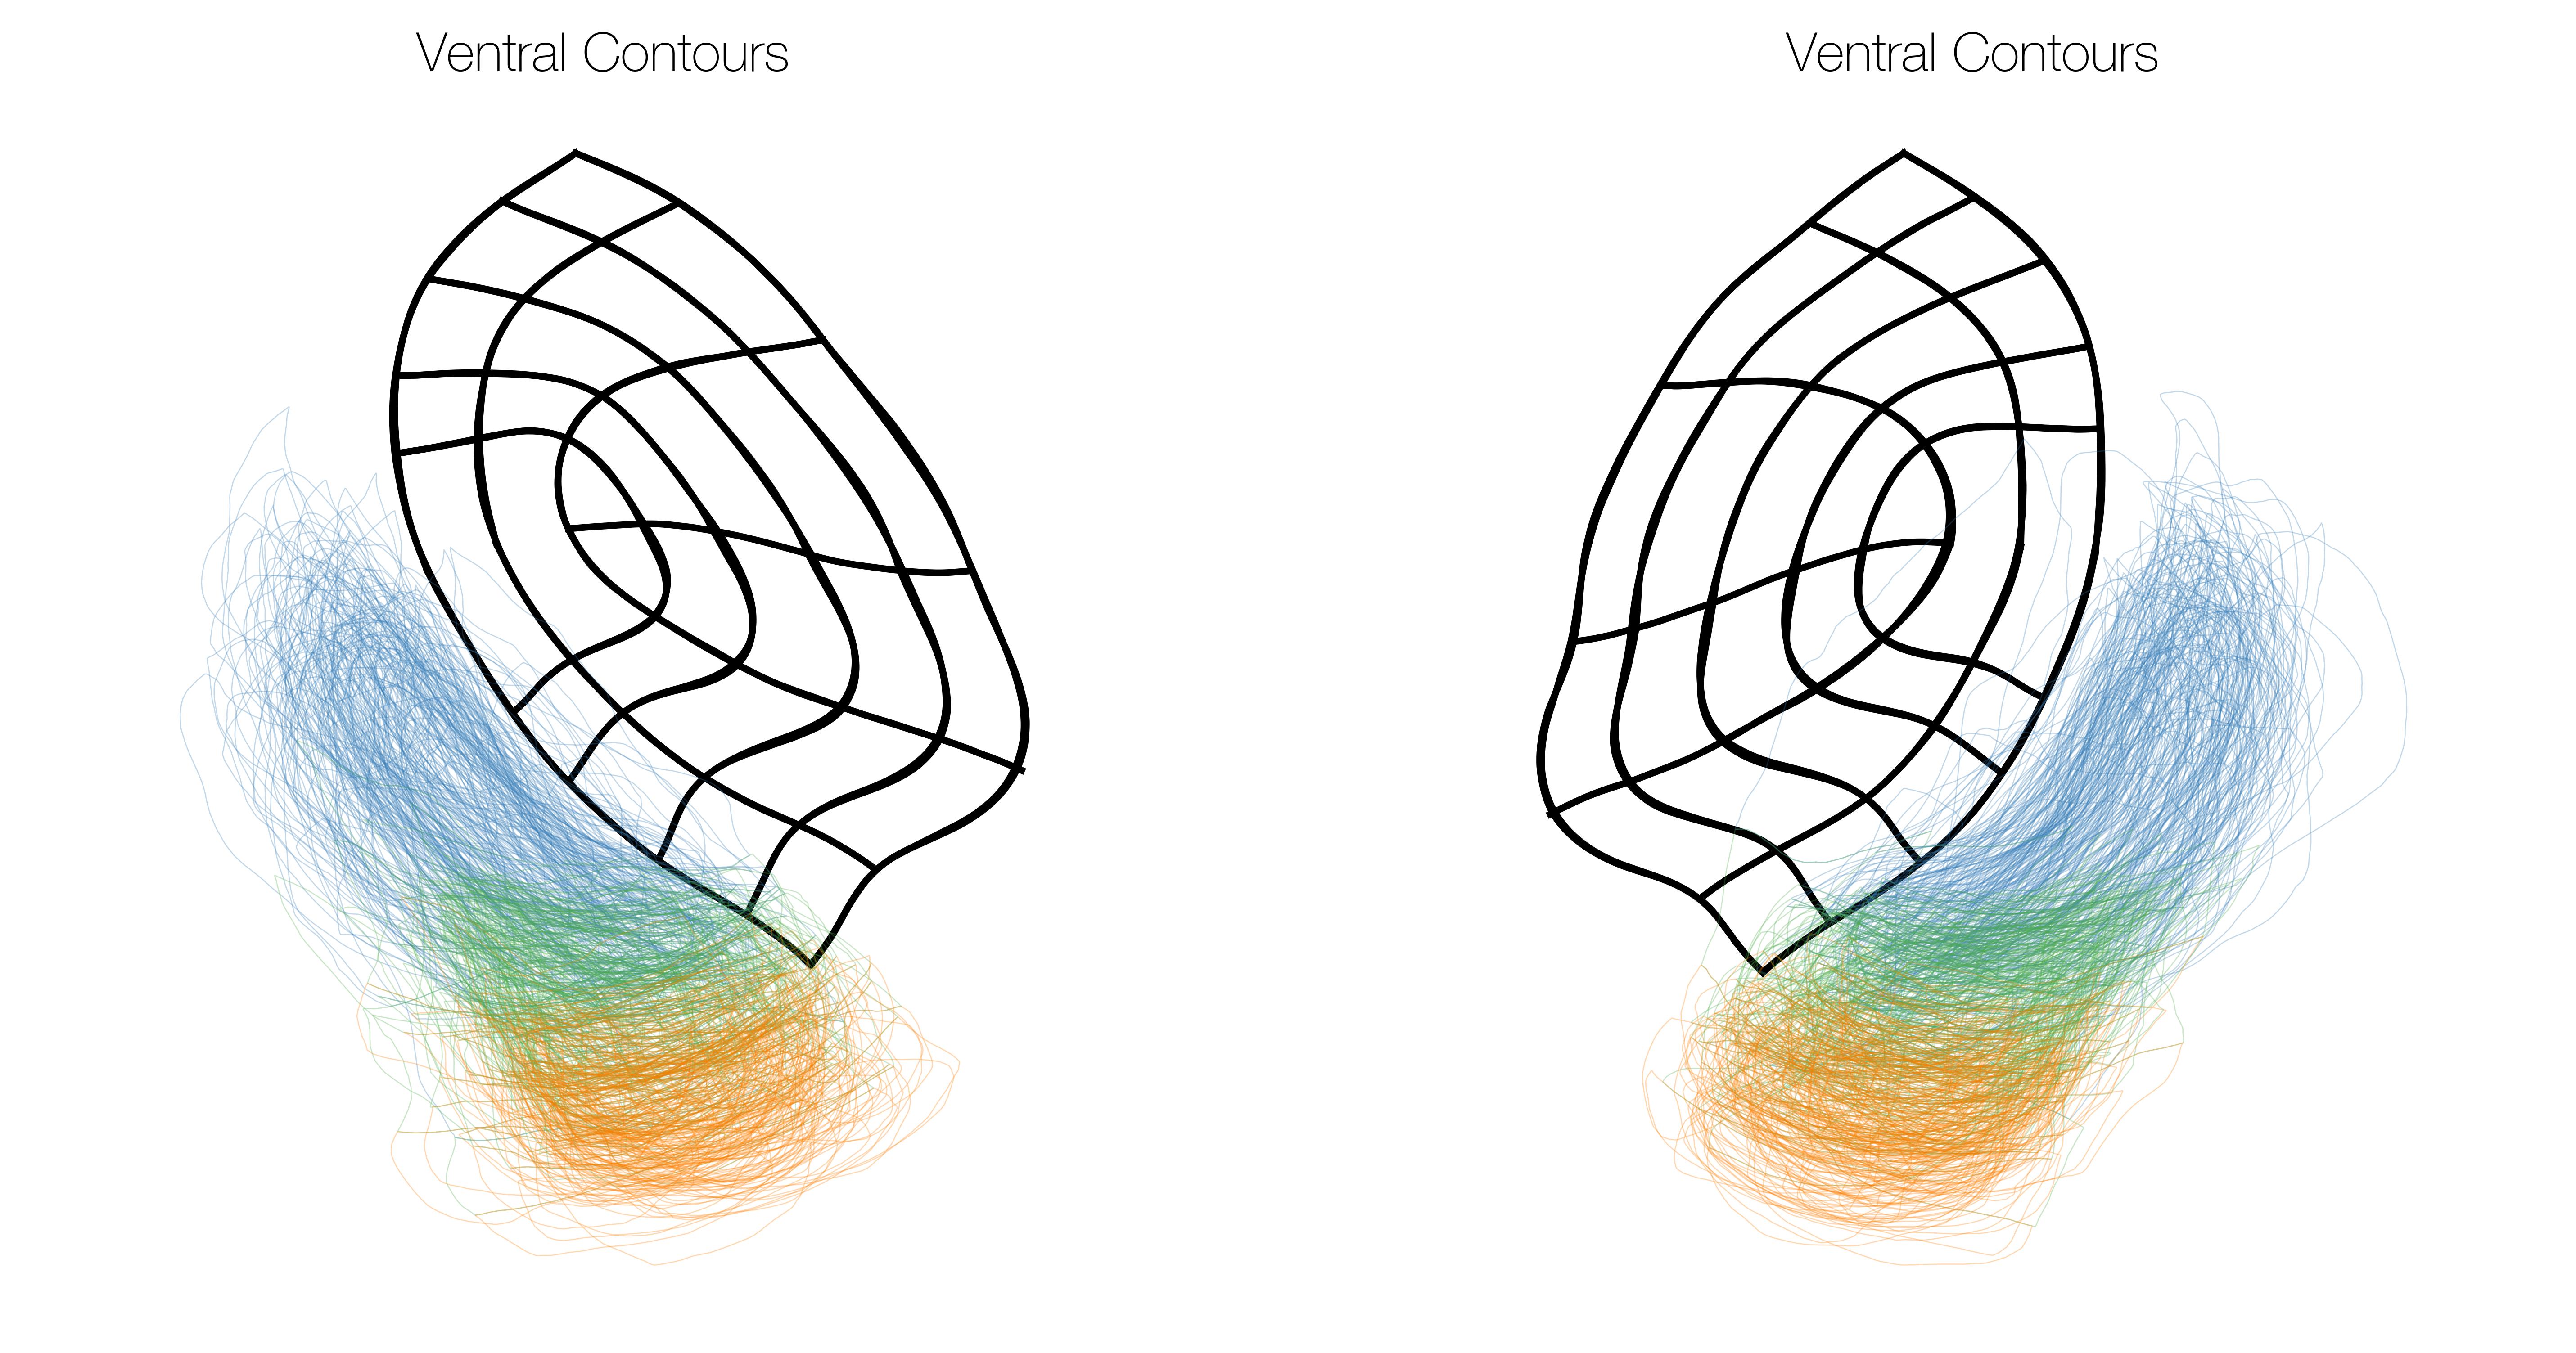

In [8]:
roi_colors = {'hV4': '#377eb8',
              'VO1': '#4daf4a',
              'VO2': '#ff7f00'}

# load the mean V1, V2, and V3 contours
meanlines = ny.load('/data/crcns2021/hcpannot-cache/annot-v123/999999.json.gz')

# define the ROIs to plot
rois = ['hV4', 'VO1', 'VO2']
fig, axes = plt.subplots (1,2, figsize=(10,5), dpi=720)

# plot the contours for the left and right hemispheres
for i, hemi in enumerate(['lh', 'rh']):
    plot_lc(sids, hemi, rois, space='fsaverage', plot_v123=True, meanlines=meanlines,
            proc_path=proc_path, ax=axes[i], colors=roi_colors)

#plt.savefig('contours.pdf', bbox_inches = 'tight')

### Align fsnative contours

```python
for hemi in ['lh', 'rh']:
    for sid in sids: 
        for r in raters:
            align_fsnative(sid, hemi, contours, r, proc_path)
```

#### Inpsect aligned fsnatvie contours

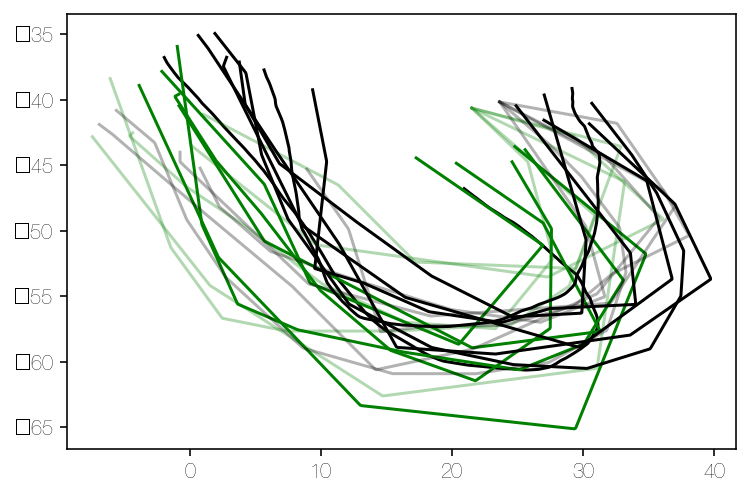

In [9]:
subject_ids = np.random.choice(sids, size=2)
plt.axis('equal')
colors = ['g','k','b']
hemi = 'lh'
contour = 'VO_outer'
for i, subject_id in enumerate(subject_ids):
    
    try:
        mean_cache_file = os.path.join(proc_path, 'fsaverage', f"cacherater_mean_{subject_id}_{hemi}_{contour}.mgz")
        coords = ny.load (mean_cache_file)
        plt.plot(coords[0], coords[1], 'k-')
        
        for r in ventral_raters:
            if r == 'mean':
                continue
            
            else:
                cache_file_aligned = os.path.join(proc_path, 'fsnative_aligned', f'cacherater_{r}_{subject_id}_{hemi}_{contour}.mgz')
                coords = ny.load(cache_file_aligned)
                plt.plot(coords[0], coords[1], c = colors[i])
                
                cache_file_aligned = os.path.join(proc_path, 'fsnative', f'cacherater_{r}_{subject_id}_{hemi}_{contour}.mgz')
                coords = ny.load(cache_file_aligned)
                plt.plot(coords[0], coords[1], c = colors[i], alpha=0.3)
        
    except Exception as e:
        print(e)